# 04 XAI-Guided Filtering (Image-Level Sweep)

This notebook performs a lightweight, reproducible filtering study using existing failure-taxonomy metrics.

Idea:
- use uncertainty/probability proxies to reject unreliable predictions
- compare baseline vs filtered metrics
- export sweep table for report figures

Current version is image-level filtering (fast and simple). You can later replace it with component-level filtering.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite')
OUT_DIR = ROOT / 'outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
files = sorted(OUT_DIR.glob('failure_taxonomy_*.csv'))
if not files:
    raise FileNotFoundError('No failure_taxonomy_*.csv found in outputs/.')

dfs = []
for f in files:
    df = pd.read_csv(f)
    if 'model_name' not in df.columns:
        df['model_name'] = f.stem.replace('failure_taxonomy_', '')
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
for c in ['tp_pixels','fp_pixels','fn_pixels','pred_pixels','gt_pixels','mean_uncertainty','mean_prob_on_fp','mean_prob_on_gt','pred_components']:
    if c in data.columns:
        data[c] = pd.to_numeric(data[c], errors='coerce')

print('Loaded rows:', len(data))
print('Models:', data['model_name'].unique())


Loaded rows: 145
Models: <StringArray>
['Unet-efficientnet-b0-imagenet_Single-TB', 'Unet-resnet34-imagenet_Single-TB']
Length: 2, dtype: str


In [3]:
def scores_from_counts(tp, fp, fn):
    iou = 1.0 if (tp + fp + fn) == 0 else tp / (tp + fp + fn)
    p = 1.0 if (tp + fp) == 0 else tp / (tp + fp)
    r = 1.0 if (tp + fn) == 0 else tp / (tp + fn)
    f1 = 0.0 if (p + r) == 0 else 2 * p * r / (p + r)
    return iou, f1, p, r


def evaluate_group(df, keep_mask):
    # If an image is rejected, prediction is replaced with empty mask.
    tp = np.where(keep_mask, df['tp_pixels'].fillna(0), 0)
    fp = np.where(keep_mask, df['fp_pixels'].fillna(0), 0)
    fn = np.where(keep_mask, df['fn_pixels'].fillna(0), df['gt_pixels'].fillna(0))

    TP = float(np.nansum(tp))
    FP = float(np.nansum(fp))
    FN = float(np.nansum(fn))

    iou, f1, precision, recall = scores_from_counts(TP, FP, FN)
    kept = int(np.nansum(keep_mask))
    total = int(len(df))
    return {
        'n_images': total,
        'kept_images': kept,
        'kept_ratio': kept / total if total else np.nan,
        'micro_iou': iou,
        'micro_f1': f1,
        'micro_precision': precision,
        'micro_recall': recall,
        'tp_pixels': TP,
        'fp_pixels': FP,
        'fn_pixels': FN,
    }


In [4]:
records = []

for model_name, g in data.groupby('model_name'):
    g = g.reset_index(drop=True)

    # Baseline (keep all)
    base_mask = np.ones(len(g), dtype=bool)
    base = evaluate_group(g, base_mask)
    base.update({'model_name': model_name, 'rule_name': 'baseline', 'u_thr': np.nan, 'fp_prob_thr': np.nan, 'min_pred_comp': np.nan})
    records.append(base)

    # Rule sweep
    u_thrs = [0.30, 0.35, 0.40, 0.45, 0.50]
    fp_prob_thrs = [0.20, 0.25, 0.30, 0.35]
    comp_thrs = [1, 2, 3, 4]

    for u in u_thrs:
        for fpp in fp_prob_thrs:
            for cmin in comp_thrs:
                keep = (
                    (g['mean_uncertainty'].fillna(1.0) <= u)
                    & (g['mean_prob_on_fp'].fillna(1.0) <= fpp)
                    & (g['pred_components'].fillna(0) >= cmin)
                )
                out = evaluate_group(g, keep.values)
                out.update({
                    'model_name': model_name,
                    'rule_name': 'uncertainty_fpProb_predComp',
                    'u_thr': u,
                    'fp_prob_thr': fpp,
                    'min_pred_comp': cmin,
                })
                records.append(out)

sweep = pd.DataFrame(records)
out_csv = OUT_DIR / 'xai_guided_filtering_sweep.csv'
sweep.to_csv(out_csv, index=False)
print('Saved:', out_csv)
print('rows:', len(sweep))
sweep.head(10)


Saved: /users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/xai_guided_filtering_sweep.csv
rows: 162


,n_images,kept_images,kept_ratio,micro_iou,micro_f1,micro_precision,micro_recall,tp_pixels,fp_pixels,fn_pixels,model_name,rule_name,u_thr,fp_prob_thr,min_pred_comp
0,72,72,1.0,0.269071,0.424044,0.495027,0.370865,23093.0,23557.0,39175.0,Unet-efficientnet-b0-imagenet_Single-TB,baseline,NaN,NaN,NaN
1,72,0,0.0,0.000000,0.000000,1.000000,0.000000,0.0,0.0,62268.0,Unet-efficientnet-b0-imagenet_Single-TB,uncertainty_fpProb_predComp,0.3,0.20,1.0
2,72,0,0.0,0.000000,0.000000,1.000000,0.000000,0.0,0.0,62268.0,Unet-efficientnet-b0-imagenet_Single-TB,uncertainty_fpProb_predComp,0.3,0.20,2.0
3,72,0,0.0,0.000000,0.000000,1.000000,0.000000,0.0,0.0,62268.0,Unet-efficientnet-b0-imagenet_Single-TB,uncertainty_fpProb_predComp,0.3,0.20,3.0
4,72,0,0.0,0.000000,0.000000,1.000000,0.000000,0.0,0.0,62268.0,Unet-efficientnet-b0-imagenet_Single-TB,uncertainty_fpProb_predComp,0.3,0.20,4.0
5,72,0,0.0,0.000000,0.000000,1.000000,0.000000,0.0,0.0,62268.0,Unet-efficientnet-b0-imagenet_Single-TB,uncertainty_fpProb_predComp,0.3,0.25,1.0
6,72,0,0.0,0.000000,0.000000,1.000000,0.000000,0.0,0.0,62268.0,Unet-efficientnet-b0-imagenet_Single-TB,uncertainty_fpProb_predComp,0.3,0.25,2.0
7,72,0,0.0,0.000000,0.000000,1.000000,0.000000,0.0,0.0,62268.0,Unet-efficientnet-b0-imagenet_Single-TB,uncertainty_fpProb_predComp,0.3,0.25,3.0
8,72,0,0.0,0.000000,0.000000,1.000000,0.000000,0.0,0.0,62268.0,Unet-efficientnet-b0-imagenet_Single-TB,uncertainty_fpProb_predComp,0.3,0.25,4.0
9,72,0,0.0,0.000000,0.000000,1.000000,0.000000,0.0,0.0,62268.0,Unet-efficientnet-b0-imagenet_Single-TB,uncertainty_fpProb_predComp,0.3,0.30,1.0


In [5]:
# Keep best setting by micro_f1 per model (excluding baseline row)
non_base = sweep[sweep['rule_name'] != 'baseline'].copy()
best_idx = non_base.groupby('model_name')['micro_f1'].idxmax()
best = non_base.loc[best_idx].copy().sort_values('model_name')

base = sweep[sweep['rule_name'] == 'baseline'][['model_name','micro_iou','micro_f1','micro_precision','micro_recall']].copy()
base = base.rename(columns={
    'micro_iou': 'base_micro_iou',
    'micro_f1': 'base_micro_f1',
    'micro_precision': 'base_micro_precision',
    'micro_recall': 'base_micro_recall',
})

report = best.merge(base, on='model_name', how='left')
report['delta_f1'] = report['micro_f1'] - report['base_micro_f1']
report['delta_iou'] = report['micro_iou'] - report['base_micro_iou']

out_csv2 = OUT_DIR / 'xai_guided_filtering_best_vs_baseline.csv'
report.to_csv(out_csv2, index=False)
print('Saved:', out_csv2)
report


Saved: /users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/xai_guided_filtering_best_vs_baseline.csv


,n_images,kept_images,kept_ratio,micro_iou,micro_f1,micro_precision,micro_recall,tp_pixels,fp_pixels,fn_pixels,...,rule_name,u_thr,fp_prob_thr,min_pred_comp,base_micro_iou,base_micro_f1,base_micro_precision,base_micro_recall,delta_f1,delta_iou
0,72,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,62268.0,...,uncertainty_fpProb_predComp,0.3,0.2,1.0,0.269071,0.424044,0.495027,0.370865,-0.424044,-0.269071
1,73,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,65516.0,...,uncertainty_fpProb_predComp,0.3,0.2,1.0,0.420781,0.592323,0.596560,0.588146,-0.592323,-0.420781


Saved: /users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/fig_xai_filtering_baseline_vs_best_f1.png


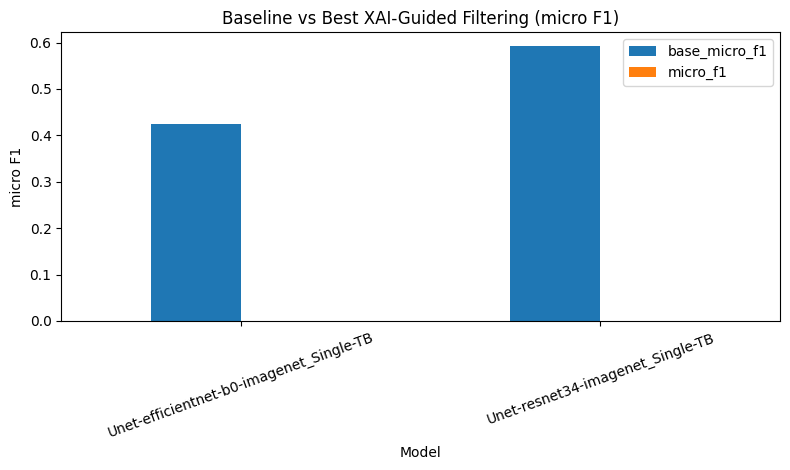

In [6]:
# Quick visualization
fig, ax = plt.subplots(figsize=(8, 4.8))
plot_df = report[['model_name','base_micro_f1','micro_f1']].copy()
plot_df = plot_df.set_index('model_name')
plot_df.plot(kind='bar', ax=ax)
ax.set_title('Baseline vs Best XAI-Guided Filtering (micro F1)')
ax.set_ylabel('micro F1')
ax.set_xlabel('Model')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
fig_path = OUT_DIR / 'fig_xai_filtering_baseline_vs_best_f1.png'
fig.savefig(fig_path, dpi=180)
print('Saved:', fig_path)
plt.show()


## Interpretation Tips

- If best filtered F1 > baseline F1, explainability signals are helping quality control.
- If recall drops too much, tighten only FP-related gates and relax uncertainty threshold.
- Next upgrade: component-level filtering from raw probability maps and connected-component stats.
